In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = "../data/processed/clustered_data.csv"
PRED_PATH = "../outputs/predictions/sentiment_predictions.csv"
OUT_DATA  = "../data/processed/severity_data.csv"
OUT_MODEL = "../models/severity_model.pkl"
OUT_FIG   = "../outputs/figures"
os.makedirs(OUT_FIG, exist_ok=True)

RESPONSE_SEVERITY = {
    "Closed with monetary relief":     5,
    "Closed with non-monetary relief": 4,
    "Closed with explanation":         3,
    "Closed without relief":           2,
    "In progress":                     2,
    "Untimely response":               5,
}

print("Setup complete")

Setup complete


In [22]:
df = pd.read_csv(DATA_PATH)

# Always derive sentiment probs from VADER — uniform coverage
df["prob_negative"] = df["compound"].apply(lambda x: max(0, -x))
df["prob_neutral"]  = df["compound"].apply(lambda x: 1 - abs(x))
df["prob_positive"] = df["compound"].apply(lambda x: max(0, x))
print("Using VADER compound as sentiment proxy (uniform coverage)")

df = df.drop_duplicates(subset="text_clean", keep="first").reset_index(drop=True)
print(f"Shape: {df.shape}")

Using VADER compound as sentiment proxy (uniform coverage)
Shape: (17181, 17)


In [23]:
print("df columns:", df.columns.tolist())
print("df shape:  ", df.shape)
print("Has complaint_id:", "complaint_id" in df.columns)

df columns: ['narrative', 'product', 'product_raw', 'issue', 'company_response', 'word_count', 'text_clean', 'text_processed', 'compound', 'sentiment', 'cluster', 'cluster_label', 'umap_x', 'umap_y', 'prob_negative', 'prob_neutral', 'prob_positive']
df shape:   (17181, 17)
Has complaint_id: False


In [24]:
df["severity_label"] = df["company_response"].map(RESPONSE_SEVERITY).fillna(3).astype(int)

import re
df["redaction_count"] = df["narrative"].apply(
    lambda t: len(re.findall(r"X{2,}", str(t)))
)
df["redaction_density"] = df["redaction_count"] / df["word_count"].clip(lower=1)

df["length_pct"] = df["word_count"].rank(pct=True)

df["cluster_int"] = df["cluster"].astype(int)

FEATURE_COLS = [
    "prob_negative", "prob_neutral", "prob_positive",
    "compound",
    "cluster_int",
    "word_count", "length_pct",
    "redaction_count", "redaction_density",
]

print(f"Features: {FEATURE_COLS}")
print(f"Severity distribution:")
for s in sorted(df["severity_label"].unique()):
    n = (df["severity_label"] == s).sum()
    print(f"  {s} {n:>6,} ({n/len(df)*100:.1f}%)")

Features: ['prob_negative', 'prob_neutral', 'prob_positive', 'compound', 'cluster_int', 'word_count', 'length_pct', 'redaction_count', 'redaction_density']
Severity distribution:
  3 12,629 (73.5%)
  4  3,606 (21.0%)
  5    946 (5.5%)


In [25]:
X = df[FEATURE_COLS].fillna(0).values
y = df["severity_label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

clf = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=RANDOM_STATE,
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print(f"Test accuracy: {(y_pred == y_test).mean():.4f}")
print(classification_report(y_test, y_pred, digits=4))

joblib.dump(clf, OUT_MODEL)
print(f"Model saved: {OUT_MODEL}")

Test accuracy: 0.7323
              precision    recall  f1-score   support

           3     0.7399    0.9806    0.8434      2527
           4     0.4535    0.0541    0.0967       721
           5     0.0000    0.0000    0.0000       189

    accuracy                         0.7323      3437
   macro avg     0.3978    0.3449    0.3134      3437
weighted avg     0.6391    0.7323    0.6404      3437

Model saved: ../models/severity_model.pkl


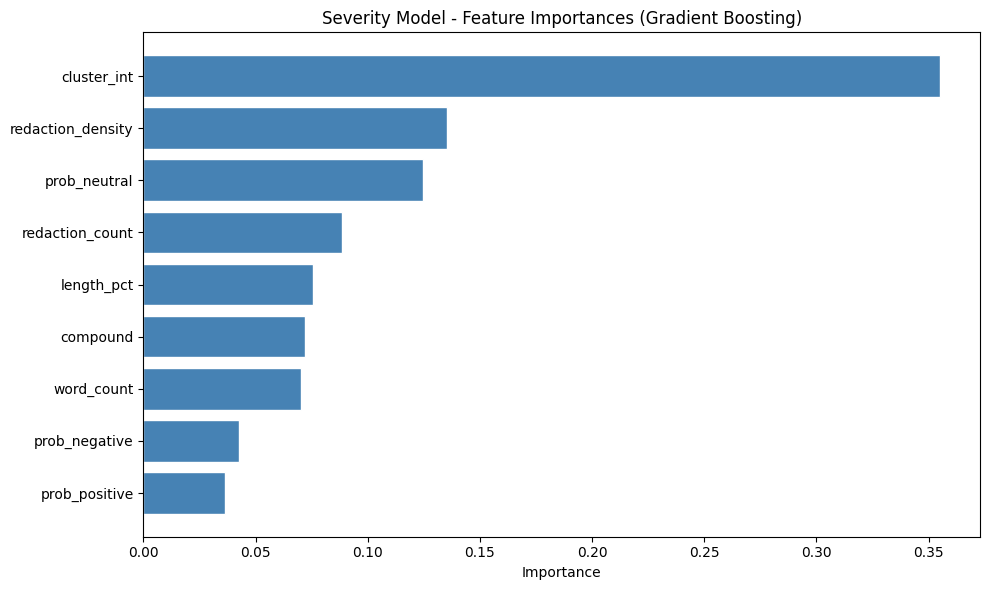

In [26]:
importances = clf.feature_importances_
feat_df = pd.DataFrame({"feature": FEATURE_COLS, "importance": importances})
feat_df = feat_df.sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feat_df["feature"], feat_df["importance"], color="steelblue", edgecolor="white")
ax.set(xlabel="Importance", title="Severity Model - Feature Importances (Gradient Boosting)")
plt.tight_layout()
plt.savefig(f"{OUT_FIG}/07_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

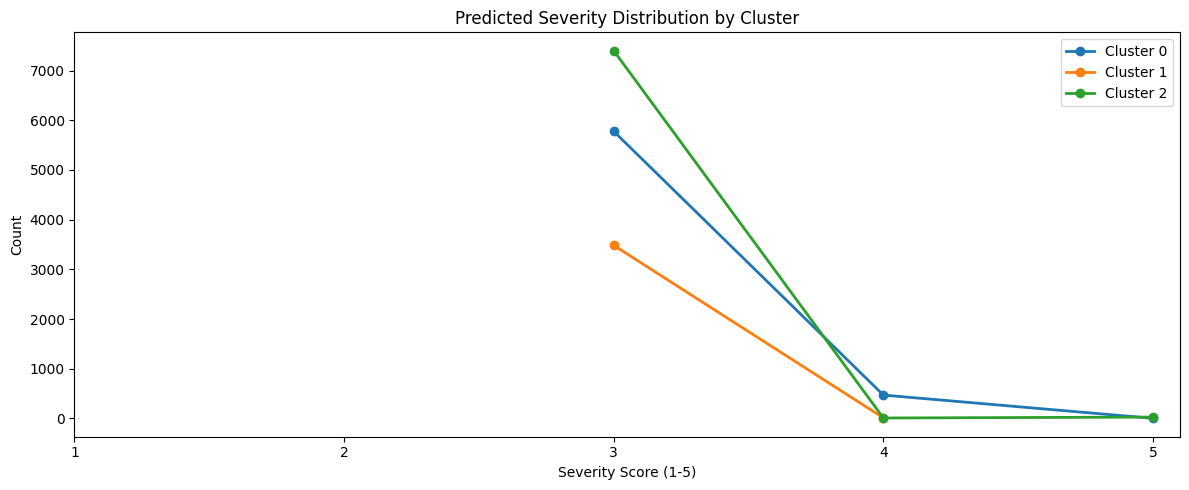

Mean predicted severity per cluster:
  Cluster 0: 3.076
  Cluster 1: 3.004
  Cluster 2: 3.009


In [27]:
df["severity_pred"] = clf.predict(df[FEATURE_COLS].fillna(0).values)

fig, ax = plt.subplots(figsize=(12, 5))
for c in sorted(df["cluster"].unique()):
    subset = df[df["cluster"] == c]
    counts = subset["severity_pred"].value_counts().sort_index()
    ax.plot(counts.index, counts.values, "o-", lw=2, label=f"Cluster {c}")

ax.set(xlabel="Severity Score (1-5)", ylabel="Count",
       title="Predicted Severity Distribution by Cluster",
       xticks=[1, 2, 3, 4, 5])
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUT_FIG}/07_severity_dist.png", dpi=150, bbox_inches="tight")
plt.show()

print("Mean predicted severity per cluster:")
for c in sorted(df["cluster"].unique()):
    mean_sev = df.loc[df["cluster"] == c, "severity_pred"].mean()
    print(f"  Cluster {c}: {mean_sev:.3f}")

In [28]:
import pandas as pd
from pathlib import Path
import time

# ─── EDIT this path ────────────────────────────────────────────────────────
RAW_PATH   = Path("../data/raw/complaints.csv")    # ← your 8 GB CSV
CHUNK_SIZE = 100_000
# ───────────────────────────────────────────────────────────────────────────

USECOLS = ["Date received", "Consumer complaint narrative"]

# Build narrative → df index lookup
# (df["narrative"] is the raw text straight from the original CSV)
wanted = {}
duplicates = 0
for idx, narr in zip(df.index, df["narrative"]):
    if narr in wanted:
        duplicates += 1
    else:
        wanted[narr] = idx

print(f"Looking for {len(wanted):,} unique narratives "
      f"({duplicates} duplicates collapsed)")
print(f"File size: {RAW_PATH.stat().st_size / 1e9:.2f} GB\n")

found_date = {}
rows_seen  = 0
t0         = time.time()

reader = pd.read_csv(
    RAW_PATH,
    usecols=USECOLS,
    chunksize=CHUNK_SIZE,
    low_memory=False,
)

for i, chunk in enumerate(reader, start=1):
    rows_seen += len(chunk)

    # Drop rows with no narrative — most of the 8 GB file is unredacted complaints
    chunk = chunk.dropna(subset=["Consumer complaint narrative"])
    if len(chunk) == 0:
        continue

    # Direct match — raw narrative against raw narrative
    hits = chunk[chunk["Consumer complaint narrative"].isin(wanted)]
    for narr, date in zip(hits["Consumer complaint narrative"],
                          hits["Date received"]):
        idx = wanted.get(narr)
        if idx is not None and idx not in found_date:
            found_date[idx] = date

    if i % 10 == 0:
        elapsed = time.time() - t0
        rate    = rows_seen / elapsed
        print(f"  chunk {i:>4} | rows seen {rows_seen:>11,} | "
              f"matched {len(found_date):>6,}/{len(wanted):,} | "
              f"{rate/1e6:.2f}M rows/s")

elapsed = time.time() - t0
print(f"\nScan complete in {elapsed:.1f}s ({rows_seen:,} rows)")
print(f"Matched: {len(found_date):,}/{len(wanted):,}")

# ─── Attach to df ──────────────────────────────────────────────────────────
df["date_received"] = pd.to_datetime(
    df.index.map(found_date), errors="coerce"
)

missing = df["date_received"].isna().sum()
if missing:
    pct = 100 * missing / len(df)
    print(f"\n⚠  {missing} rows ({pct:.2f}%) have no date_received")
    if pct > 1.0:
        print("   This is suspicious — check for narrative truncation or encoding diffs")
else:
    print("\n✓ All rows matched")

print(f"\nDate range: {df['date_received'].min()} → {df['date_received'].max()}")
print(f"Final df:   {df.shape}")
print(f"Columns:    {df.columns.tolist()}")

# ─── Save ──────────────────────────────────────────────────────────────────
df.to_csv("../data/processed/severity_data.csv", index=False)
print(f"\nSaved severity_data.csv")

Looking for 17,181 unique narratives (0 duplicates collapsed)
File size: 8.59 GB

  chunk   10 | rows seen   1,000,000 | matched  2,344/17,181 | 0.20M rows/s
  chunk   20 | rows seen   2,000,000 | matched  3,698/17,181 | 0.21M rows/s
  chunk   30 | rows seen   3,000,000 | matched  4,869/17,181 | 0.22M rows/s
  chunk   40 | rows seen   4,000,000 | matched  6,053/17,181 | 0.23M rows/s
  chunk   50 | rows seen   5,000,000 | matched  7,204/17,181 | 0.23M rows/s
  chunk   60 | rows seen   6,000,000 | matched  8,293/17,181 | 0.24M rows/s
  chunk   70 | rows seen   7,000,000 | matched  9,388/17,181 | 0.24M rows/s
  chunk   80 | rows seen   8,000,000 | matched 10,472/17,181 | 0.25M rows/s
  chunk   90 | rows seen   9,000,000 | matched 11,473/17,181 | 0.25M rows/s
  chunk  100 | rows seen  10,000,000 | matched 12,533/17,181 | 0.25M rows/s
  chunk  110 | rows seen  11,000,000 | matched 13,541/17,181 | 0.25M rows/s
  chunk  120 | rows seen  12,000,000 | matched 14,575/17,181 | 0.25M rows/s
  chun

In [19]:
df["severity_score"] = df["severity_pred"]

KEEP_COLS = [
    "narrative", "product", "issue", "company_response",
    "word_count", "text_clean", "text_processed",
    "compound", "sentiment",
    "cluster", "cluster_label",
    "severity_label", "severity_score",
    "prob_negative", "prob_neutral", "prob_positive",
    "redaction_count", "redaction_density",
]

df[KEEP_COLS].to_csv(OUT_DATA, index=False)
print(f"Saved: {OUT_DATA} ({len(df):,} rows x {len(KEEP_COLS)} cols)")
print(f"Top-10 highest severity complaints:")
top10 = df.nlargest(10, "severity_score")[["severity_score", "sentiment", "cluster", "narrative"]]
for _, row in top10.iterrows():
    print(f"  [{row['severity_score']}] {row['narrative'][:120]}")

Saved: ../data/processed/severity_data.csv (17,181 rows x 18 cols)
Top-10 highest severity complaints:
  [5] On XX/XX/XXXX my phone was stolen Im a XXXX XXXX. XX/XX/XXXX My roommate provided me with old phone I went to phone stor
  [5] Dear Consumer Finance, I am the victim of banking fraud of Wells Fargo. 

On the morning of XX/XX/2021, I received a cal
  [5] On XX/XX/2023 approximately XXXX dollars was used at a XXXX and later a XXXX on a stolen US Bank credit card after thiev
  [5] Chase Total Checking + Chase Freedom XXXX XXXX {$520.00} Bonus. 

Bonus requirements : Open a Chase Total Checking accou
  [5] My Chase credit card was billed for a service by the company at the following address. 

XXXX XXXX XXXX XXXXXXXX XXXX XX
  [5] In regards to the XX/XX/XXXX transaction from the Merchant : XXXX XXXX XXXX in the Amount : {$2400.00}, I attest that ne
  [5] On XX/XX/2020 I opened a checking and savings account with First Citizens Bank of XXXX It was advertised that I would re
  [5] I 

In [20]:
import numpy as np, joblib

wc_sorted = np.sort(df["word_count"].values.astype(float))
joblib.dump(wc_sorted, "../models/wc_sorted.pkl")
print(f"Saved word_count CDF: {wc_sorted.shape}")

Saved word_count CDF: (17181,)
